In [2]:
import cv2
import os
import imageio
from tqdm import tqdm
import pdb
import matplotlib.pyplot as plt
import numpy as np
import torch

import json
import pickle
import time

import scipy
import scipy.signal as signal
from scipy.io import loadmat
from scipy import ndimage

from sl_utils import get_code_all, fast_sl_rec, \
    disp_warp_batch, sl_simu_batch, fast_sl_rec_cnc
from IO import *

if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'
## if has GPU, use cuda

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Synthetic Data

Here we select 4 codes for comparison, it is straight-forward to try out other codes in the "codes" folder.

/var/folders/f9/3xcm6pwx3sbdrczk8dsrmd9m0000gn/T/ipykernel_69173/2658727313.py:13: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  intensity = imageio.imread('data/im1.png').astype(np.float32)/255.0


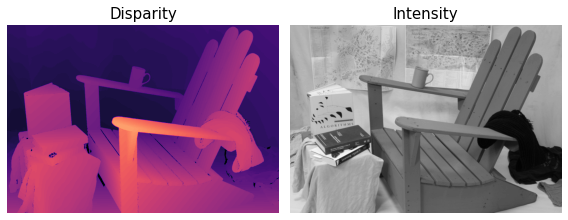

In [3]:
## load data
disp, _ = readPFM(os.path.join('data/disp1.pfm'))
disp[disp == np.inf] = 0
disp[disp == np.nan] = 0
disp = cv2.resize(disp/3, (disp.shape[1]//4, disp.shape[0]//4), interpolation = cv2.INTER_AREA)
disp = np.clip(disp, 0.0, 100.0)
disp = disp.astype(np.int64).astype(np.float32)
fig, ax = plt.subplots(1,2,figsize = (8,4))
ax[0].imshow(disp, vmin = 0.0, vmax = 100.0, cmap = 'magma')
ax[0].axis('off')
ax[0].set_title('Disparity', fontsize = 15.0)

intensity = imageio.imread('data/im1.png').astype(np.float32)/255.0
intensity = (intensity[...,1] + 1)/2
intensity = cv2.resize(intensity, (intensity.shape[1]//4, intensity.shape[0]//4), interpolation = cv2.INTER_AREA)
ax[1].imshow(intensity, cmap = 'gray')
ax[1].axis('off')
ax[1].set_title('Intensity', fontsize = 15.0)
plt.tight_layout()

In [4]:
def sl_synthetic(code, disp, img):
    code1d = torch.from_numpy(code.astype(np.float32)).to(device)
    code1d_bias = torch.sum(code1d**2, dim = 1).reshape(-1,1)
    cam_imgs = sl_simu_batch(np.repeat(code[np.newaxis, ...], resx, axis = 0), intensity, \
                             disp, pr, sr, poiss_K, noise_level, t_exp, 100)
    cam_imgs_t = cam_imgs.squeeze().view(cam_imgs.shape[0], -1)
    corr_idx = fast_sl_rec(code1d, code1d_bias, cam_imgs_t, resx, resy)
    del cam_imgs_t
    return corr_idx

## Structured light simualtions

/Users/zhanghaosun/miniconda3/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1666646703877/work/aten/src/ATen/native/TensorShape.cpp:3191.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/Users/zhanghaosun/miniconda3/lib/python3.9/site-packages/torch/nn/functional.py:4227: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


Non-redundant code; number of frames: 10, error rate: 13.34%
ECC(22,10) code; number of frames: 22, error rate: 0.89%
Brute-force searched code; number of frames: 22, error rate: 1.4%
Optimized code; number of frames: 22, error rate: 7.6%


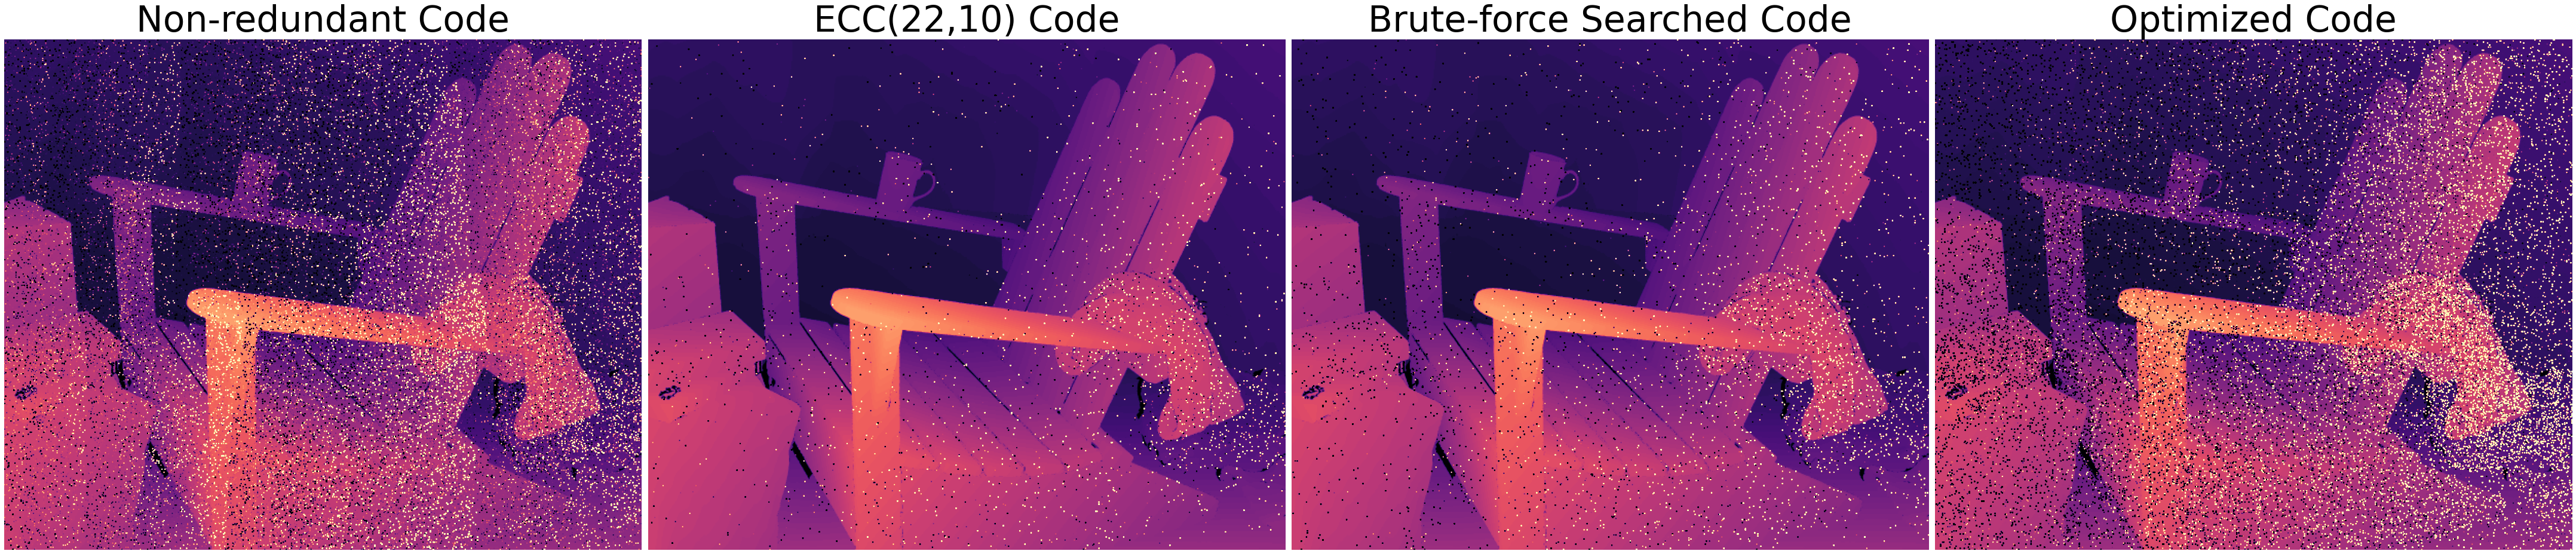

In [5]:
"""
noise & camera settings
"""
noise_level = 0.001 ## Gaussian readout noise
t_exp = 1.0 ## exposure time
pr = 0.7 ## projector light intensity
sr = 2.0 ## ambient light intensity
poiss_K = 3.0 ## Poisson noise coefficient
resy = 720 ## horizontal resolution
resx = 497 ## vertical resolution

"""
Gray code
"""
code = get_code_all(np.load('codes/gray_code.npy'), resy)
corr_idx = sl_synthetic(code, disp, intensity)

fig, ax = plt.subplots(1,4,figsize = (60,15))
x, y = np.meshgrid(np.arange(disp.shape[1]), np.arange(disp.shape[0]))

ax[0].imshow(x[:,100:] - corr_idx[:,100:], vmin = 0.0, vmax = 100.0, cmap = 'magma')
ax[0].axis('off')
ax[0].set_title('Non-redundant Code', fontsize = 60.0)

print('Non-redundant code; number of frames: {}, error rate: {}%'.format(code.shape[1] - 2,
    np.round(np.sum(np.abs(x[:,100:] - corr_idx[:,100:] - \
        disp[:,100:]) >= 2.0)/disp[:,100:].shape[0]/disp[:,100:].shape[1]*100, 2)))

"""
ECC(22,10) code
"""
code = get_code_all(np.load('codes/ecc/golay22_code.npy'), resy)
corr_idx = sl_synthetic(code, disp, intensity)

ax[1].imshow(x[:,100:] - corr_idx[:,100:], vmin = 0.0, vmax = 100.0, cmap = 'magma')
ax[1].axis('off')
ax[1].set_title('ECC(22,10) Code', fontsize = 60.0)
print('ECC(22,10) code; number of frames: {}, error rate: {}%'.format(code.shape[1] - 2,
    np.round(np.sum(np.abs(x[:,100:] - corr_idx[:,100:] - \
        disp[:,100:]) >= 2.0)/disp[:,100:].shape[0]/disp[:,100:].shape[1]*100.0, 2)))

"""
Brute-force code
"""
code = get_code_all(np.load('codes/brute-force/pdisk_search_22code.npy'), resy)
corr_idx = sl_synthetic(code, disp, intensity)

ax[2].imshow(x[:,100:] - corr_idx[:,100:], vmin = 0.0, vmax = 100.0, cmap = 'magma')
ax[2].axis('off')
ax[2].set_title('Brute-force Searched Code', fontsize = 60.0)
print('Brute-force searched code; number of frames: {}, error rate: {}%'.format(code.shape[1] - 2,
    np.round(np.sum(np.abs(x[:,100:] - corr_idx[:,100:] - \
        disp[:,100:]) >= 2.0)/disp[:,100:].shape[0]/disp[:,100:].shape[1]*100.0, 2)))


"""
Optimized code
"""
code = get_code_all(np.load('codes/optimized/highnoise_code.npy'), resy)
corr_idx = sl_synthetic(code, disp, intensity)

ax[3].imshow(x[:,100:] - corr_idx[:,100:], vmin = 0.0, vmax = 100.0, cmap = 'magma')
ax[3].axis('off')
ax[3].set_title('Optimized Code', fontsize = 60.0)
print('Optimized code; number of frames: {}, error rate: {}%'.format(code.shape[1] - 2,
    np.round(np.sum(np.abs(x[:,100:] - corr_idx[:,100:] - \
        disp[:,100:]) >= 2.0)/disp[:,100:].shape[0]/disp[:,100:].shape[1]*100.0, 2)))

plt.tight_layout()

## Code Look-up-table (Fig.3 (c) in paper)

In [6]:
with open('codes/ecc/code_lut.pickle', 'rb') as f:
    codes = pickle.load(f)
for kk in codes.keys():
    code = codes[kk]
    print(f'{kk}; number of frames (k): {code.shape[0]}; k0: {int(np.log2(code.shape[1]))}')

golay_24_12_family_k22_k010; number of frames (k): 22; k0: 10
golay_24_12_family_k21_k09; number of frames (k): 21; k0: 9
golay_24_12_family_k20_k08; number of frames (k): 20; k0: 8
golay_24_12_family_k19_k07; number of frames (k): 19; k0: 7
golay_24_12_family_k18_k06; number of frames (k): 18; k0: 6
golay_24_12_family_k17_k05; number of frames (k): 17; k0: 5
golay_23_12_family_k16_k05; number of frames (k): 16; k0: 5
golay_23_12_family_k21_k010; number of frames (k): 21; k0: 10
golay_23_12_family_k20_k09; number of frames (k): 20; k0: 9
golay_23_12_family_k19_k08; number of frames (k): 19; k0: 8
golay_23_12_family_k18_k07; number of frames (k): 18; k0: 7
golay_23_12_family_k17_k06; number of frames (k): 17; k0: 6
rm_4_2_family_k15_k010; number of frames (k): 15; k0: 10
rm_4_2_family_k14_k09; number of frames (k): 14; k0: 9
rm_4_2_family_k13_k08; number of frames (k): 13; k0: 8
rm_4_2_family_k12_k07; number of frames (k): 12; k0: 7
rm_4_2_family_k11_k06; number of frames (k): 11; k0: 6

## Real-world Data

Please first download real-world captured data from "https://drive.google.com/drive/folders/1Ddbp8xmHCgepbmv1-ycSyP65MuB9AbvD?usp=share_link"
Unzip all the contents to "real_data" folder

Non-redundant, Projector/Ambient Ratio=0.097, Error Rate: 23.32%
Non-redundant, Projector/Ambient Ratio=0.136, Error Rate: 5.64%
ECC(15,10), Projector/Ambient Ratio=0.097, Error Rate: 12.68%
ECC(15,10), Projector/Ambient Ratio=0.136, Error Rate: 3.59%
ECC(22,10), Projector/Ambient Ratio=0.097, Error Rate: 10.4%
ECC(22,10), Projector/Ambient Ratio=0.136, Error Rate: 3.21%


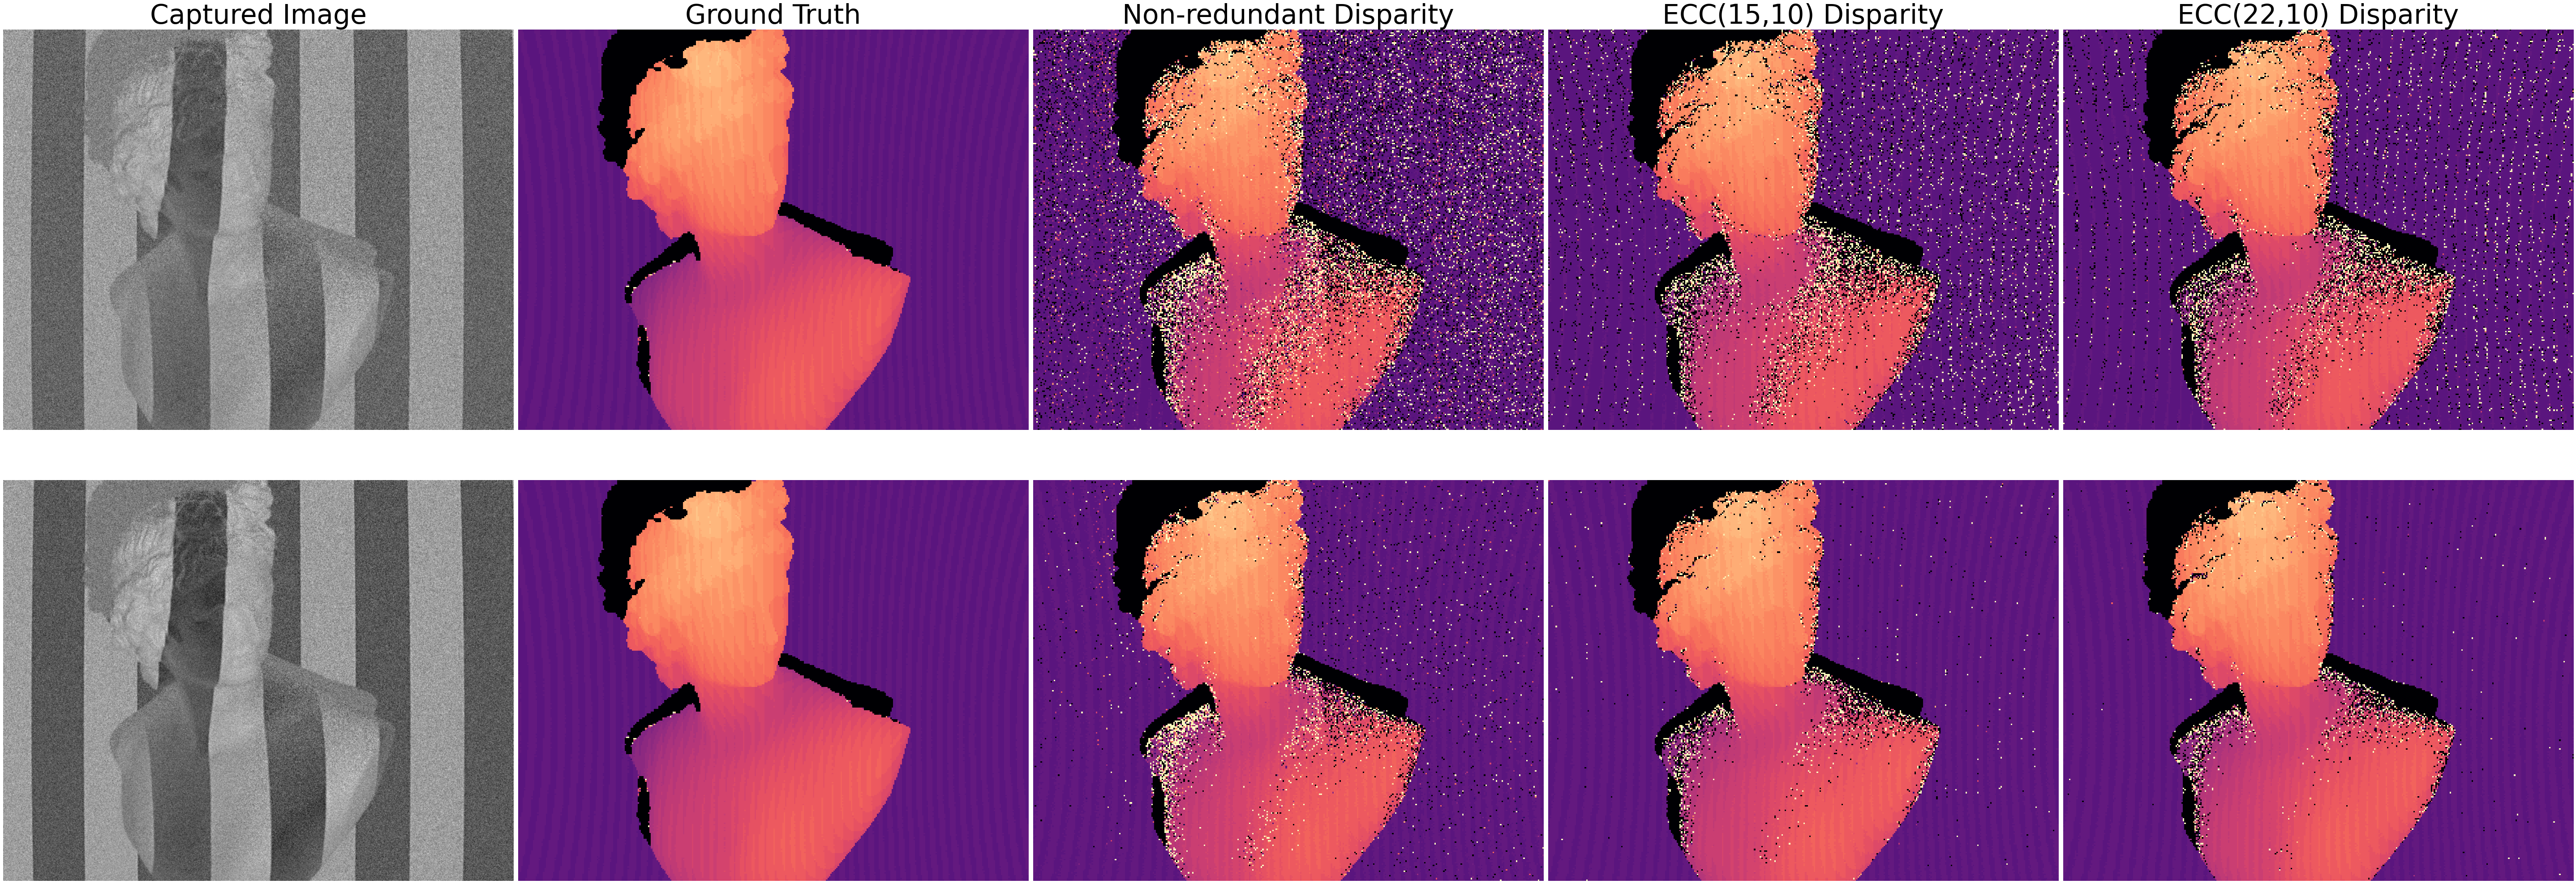

In [7]:
H = 1536 
W = 2048

data_dir = "real_data"
corr_calib = np.load(os.path.join(data_dir, 'david_data/corr_calib.npy'))

prs = [0.097, 0.136]
cnames = ['Non-redundant', 'ECC(15,10)', 'ECC(22,10)']
clength = [10,15,22]
codes = [torch.from_numpy(scipy.io.loadmat(os.path.join(data_dir, 'david_data/c_vec_gray.mat'))['c_vec'].astype(np.float32).transpose(1,0)), \
         torch.from_numpy(scipy.io.loadmat(os.path.join(data_dir, 'david_data/c_vec_Reed_Muller_pseudogray.mat'))['c_vec'].astype(np.float32).transpose(1,0)), \
         torch.from_numpy(scipy.io.loadmat(os.path.join(data_dir, 'david_data/c_vec_Golay_gray.mat'))['c_vec'].astype(np.float32).transpose(1,0))]

gt = np.load(os.path.join(data_dir, 'david_data/real_gt.npy'))
mask = (np.abs(gt) <= 50).astype(np.float32)
mask[mask == 0] = -100.0
box_filter = np.ones((5,5))/25
mask = signal.convolve2d(mask, box_filter, boundary='symm', mode='same') < 1
gt[mask] = -100

fig, ax = plt.subplots(2,5,figsize = (80,30))
ax[0,1].imshow(gt[::2,::2], vmin = -10.0, vmax = 30.0, cmap = 'magma')
ax[1,1].imshow(gt[::2,::2], vmin = -10.0, vmax = 30.0, cmap = 'magma')
ax[0,1].set_title('Ground Truth', fontsize = 60.0)

for jj, cname in enumerate(cnames):
    for idx, pr in enumerate(prs):
        cam_imgs = []
        for ii in range(1,clength[jj]+1):
            img = np.fromfile(os.path.join(data_dir, 'david_data/{}/{:.3f}/cam_{}.raw'.format(cname, pr, ii)), dtype = np.uint16).astype(np.float32)/4096
            img = img.reshape(H, W)[100:1200,400:1800]
            img = (img[::2,::2] + img[1::2,::2] + img[::2,1::2] + img[1::2,1::2])/4
            nimg = np.fromfile(os.path.join(data_dir, 'david_data/{}/{:.3f}/cam_{}.raw'.format(cname, pr, ii+clength[jj]+2)), dtype = np.uint16).astype(np.float32)/4096
            nimg = nimg.reshape(H, W)[100:1200,400:1800]
            nimg = (nimg[::2,::2] + nimg[1::2,::2] + nimg[::2,1::2] + nimg[1::2,1::2])/4

            cam_imgs.append(img - nimg)
        
        ax[idx, 0].imshow(cam_imgs[5], cmap = 'gray')
        ax[0,0].set_title('Captured Image', fontsize = 60.0)
        cam_imgs = torch.from_numpy(np.asarray(cam_imgs)).unsqueeze(1)

        corr_idx = fast_sl_rec_cnc(codes[jj], cam_imgs.view(cam_imgs.shape[0],-1), 550, 700)
        disp = corr_calib - corr_idx
        disp[mask] = -100
        
        er = np.sum(np.abs(gt*(1-mask) - disp*(1-mask)) > 1.0)/gt.shape[0]/gt.shape[1]
        print('{}, Projector/Ambient Ratio={}, Error Rate: {}%'.format(cname, pr, np.round(er*100, 2)))
        ax[idx, jj+2].imshow(disp[::2,::2], vmin = -10.0, vmax = 30.0, cmap = 'magma')
        ax[0, jj+2].set_title('{} Disparity'.format(cname), fontsize = 60.0)

for jj in range(5):
    for idx in range(2):
        ax[idx, jj].axis('off')
plt.tight_layout()